# Лабораторная работа 1

## Часть 1: Настройка окружения и подготовка данных

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.datasets import make_classification, make_moons, load_iris
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix,  roc_curve, auc
from ipywidgets import interact, IntSlider

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

def generate_data():
    n_samples = 300
    X_lin, y_lin = make_classification(n_samples=n_samples, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, class_sep=2.0, random_state=RANDOM_STATE)
    X_noisy, y_noisy = make_classification(n_samples=n_samples, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, class_sep=0.8, flip_y=0.1, random_state=RANDOM_STATE)
    X_moon, y_moon = make_moons(n_samples=n_samples, noise=0.2, random_state=RANDOM_STATE)
    return (X_lin, y_lin), (X_noisy, y_noisy), (X_moon, y_moon)

(X_l, y_l), (X_n, y_n), (X_m, y_m) = generate_data()

## Часть 2: Исследование работы персептрона
### 2.1 Базовое применение и интерактивная динамика обучения

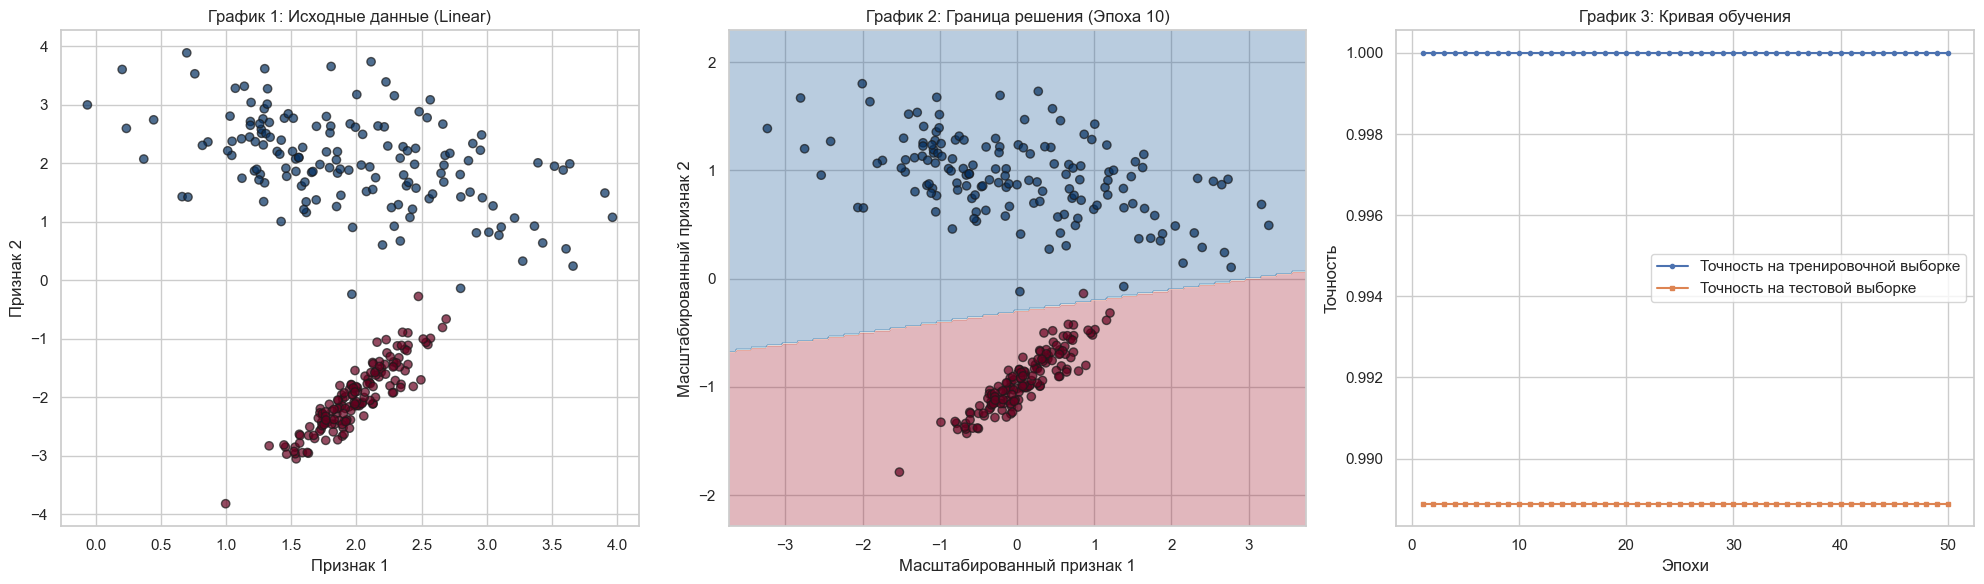

In [ ]:
def plot_all_visualizations(dataset_name='Linear'):
    if dataset_name == 'Linear':
        X, y = X_l, y_l
    elif dataset_name == 'Noisy':
        X, y = X_n, y_n
    else:
        X, y = X_m, y_m

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    X_s = scaler.transform(X)

    # Граф 1: Исходные данные
    plt.figure(figsize=(20, 6))
    plt.subplot(1, 3, 1)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolors="k", alpha=0.7)
    plt.title(f"График 1: Исходные данные ({dataset_name})")
    plt.xlabel("Признак 1")
    plt.ylabel("Признак 2")

    # Граф 2: Граница решения после 10 эпох обучения
    plt.subplot(1, 3, 2)
    epoch_for_boundary = 10
    clf_boundary = Perceptron(max_iter=epoch_for_boundary, tol=None, random_state=RANDOM_STATE)
    clf_boundary.fit(X_train_s, y_train)

    h = 0.02
    x_min, x_max = X_s[:, 0].min() - 0.5, X_s[:, 0].max() + 0.5
    y_min, y_max = X_s[:, 1].min() - 0.5, X_s[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid_s = np.c_[xx.ravel(), yy.ravel()]
    Z = clf_boundary.predict(grid_s).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
    plt.scatter(X_s[:, 0], X_s[:, 1], c=y, cmap="RdBu", edgecolors="k", alpha=0.7)
    plt.title(f"График 2: Граница решения (Эпоха {epoch_for_boundary})")
    plt.xlabel("Масштабированный признак 1")
    plt.ylabel("Масштабированный признак 2")

    # Граф 3 Точность обучения и тестирования в зависимости от количества эпох
    plt.subplot(1, 3, 3)
    epochs_range = range(1, 51)
    train_accuracies = []
    test_accuracies = []

    for epoch in epochs_range:
        clf_lc = Perceptron(max_iter=epoch, tol=None, random_state=RANDOM_STATE)
        clf_lc.fit(X_train_s, y_train)
        train_accuracies.append(accuracy_score(y_train, clf_lc.predict(X_train_s)))
        test_accuracies.append(accuracy_score(y_test, clf_lc.predict(X_test_s)))

    plt.plot(epochs_range, train_accuracies, label='Точность на тренировочной выборке', marker='o', markersize=3)
    plt.plot(epochs_range, test_accuracies, label='Точность на тестовой выборке', marker='s', markersize=3)
    plt.title("График 3: Кривая обучения")
    plt.xlabel("Эпохи")
    plt.ylabel("Точность")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_all_visualizations('Linear')

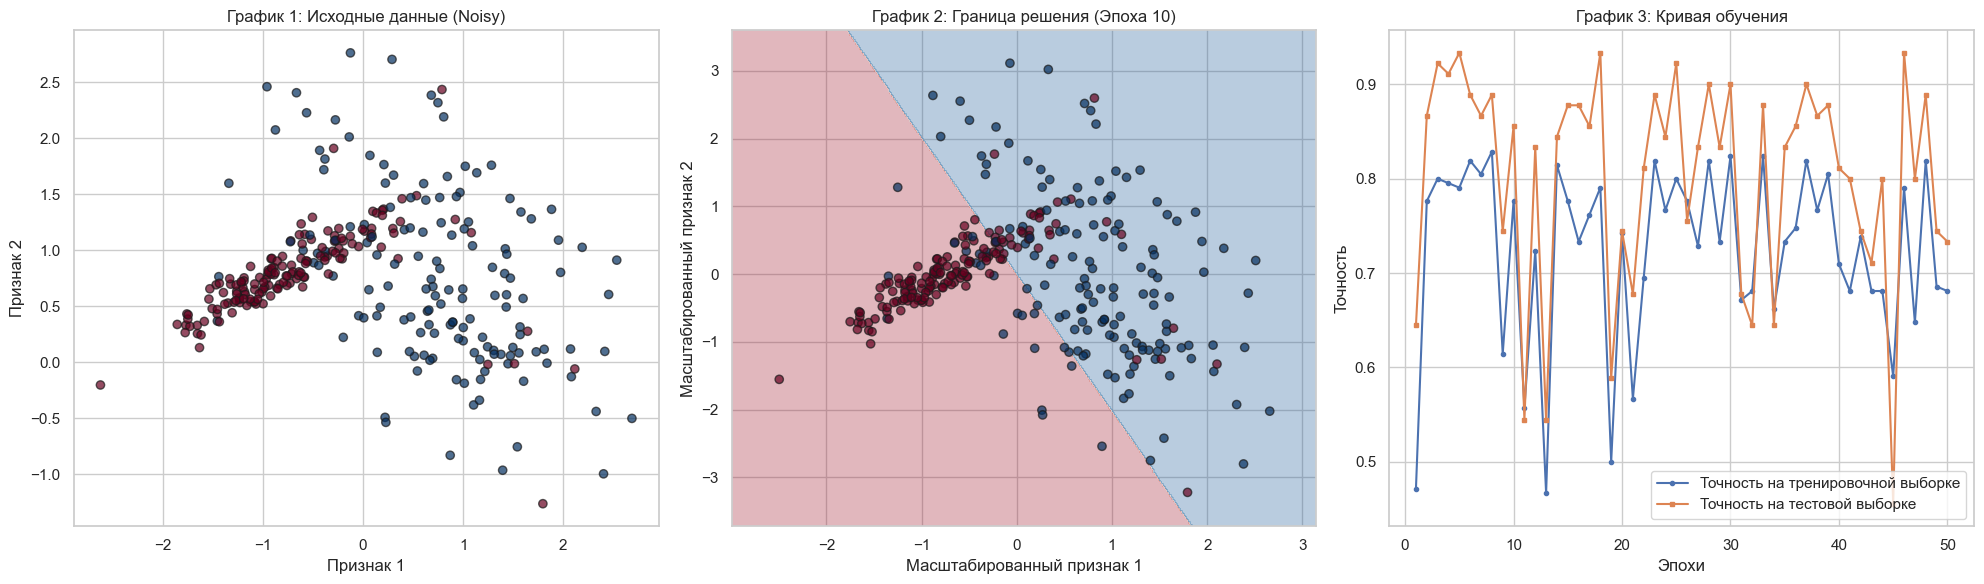

In [14]:
plot_all_visualizations('Noisy')

In [ ]:
def plot_interactive_perceptron_only(dataset_name='Linear'):
    if dataset_name == 'Linear':
        X, y = X_l, y_l
    elif dataset_name == 'Noisy':
        X, y = X_n, y_n
    else:
        X, y = X_m, y_m

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    X_s = scaler.transform(X)

    h = 0.02
    x_min, x_max = X_s[:, 0].min() - 0.5, X_s[:, 0].max() + 0.5
    y_min, y_max = X_s[:, 1].min() - 0.5, X_s[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid_s = np.c_[xx.ravel(), yy.ravel()]

    def update(epoch=10):
        clf = Perceptron(max_iter=epoch, tol=None, random_state=RANDOM_STATE)
        clf.fit(X_train_s, y_train)
        Z = clf.predict(grid_s).reshape(xx.shape)
        
        plt.figure(figsize=(10, 6))
        plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
        plt.scatter(X_s[:, 0], X_s[:, 1], c=y, cmap="RdBu", edgecolors="k")
        acc = accuracy_score(y_test, clf.predict(X_test_s))
        plt.title(f"Датасет: {dataset_name} | Эпоха: {epoch} | Accuracy: {acc:.2f}")
        plt.show()

    interact(update, epoch=IntSlider(min=1, max=10, step=1, value=1))

plot_interactive_perceptron_only('Linear')

interactive(children=(IntSlider(value=1, description='epoch', max=50, min=1), Output()), _dom_classes=('widget…

### 2.2 Влияние гиперпараметров

In [3]:
etas = [0.0001, 0.001, 0.01, 0.1, 1.0]
X_train, X_test, y_train, y_test = train_test_split(X_n, y_n, test_size=0.3, random_state=RANDOM_STATE)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

results_eta = []
for eta in etas:
    clf = Perceptron(eta0=eta, random_state=RANDOM_STATE)
    clf.fit(X_train_s, y_train)
    results_eta.append({'eta': eta, 'iters': clf.n_iter_, 'acc': accuracy_score(y_test, clf.predict(X_test_s))})

print("Влияние скорости обучения (eta0):")
print(pd.DataFrame(results_eta))

Влияние скорости обучения (eta0):
      eta  iters       acc
0  0.0001      6  0.888889
1  0.0010      6  0.888889
2  0.0100      6  0.888889
3  0.1000     10  0.855556
4  1.0000     10  0.855556


## Часть 3: Анализ ограничений персептрона

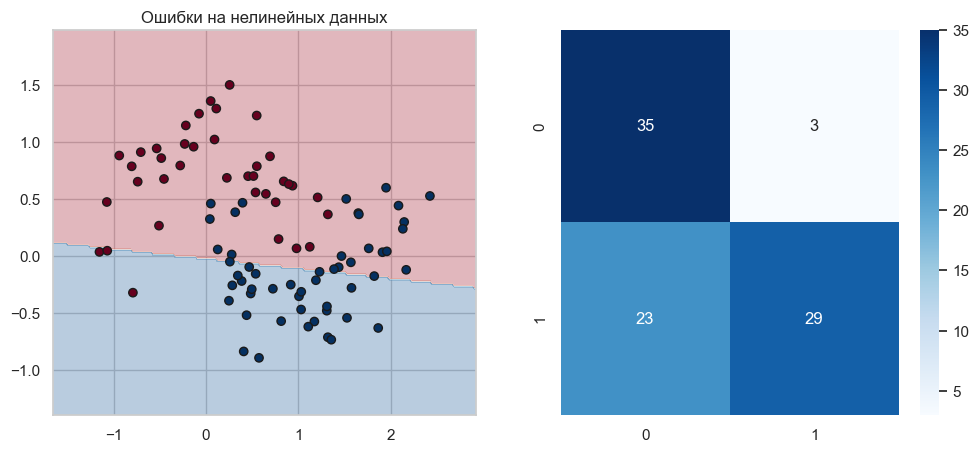

In [4]:
clf = Perceptron(random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(X_m, y_m, test_size=0.3, random_state=RANDOM_STATE)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
clf.fit(X_train_s, y_train)
y_pred = clf.predict(X_test_s)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
h = 0.02
x_min, x_max = X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5
y_min, y_max = X_test[:, 1].min() - 0.5, X_test[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = clf.predict(scaler.transform(np.c_[xx.ravel(), yy.ravel()])).reshape(xx.shape)
axes[0].contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="RdBu", edgecolors="k")
axes[0].set_title("Ошибки на нелинейных данных")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[1])
plt.show()

## Часть 4: Классификация ирисов Фишера

Лучшие параметры: {'eta0': 1e-05, 'max_iter': 1, 'penalty': None}
Лучшая точность на кросс-валидации: 0.99


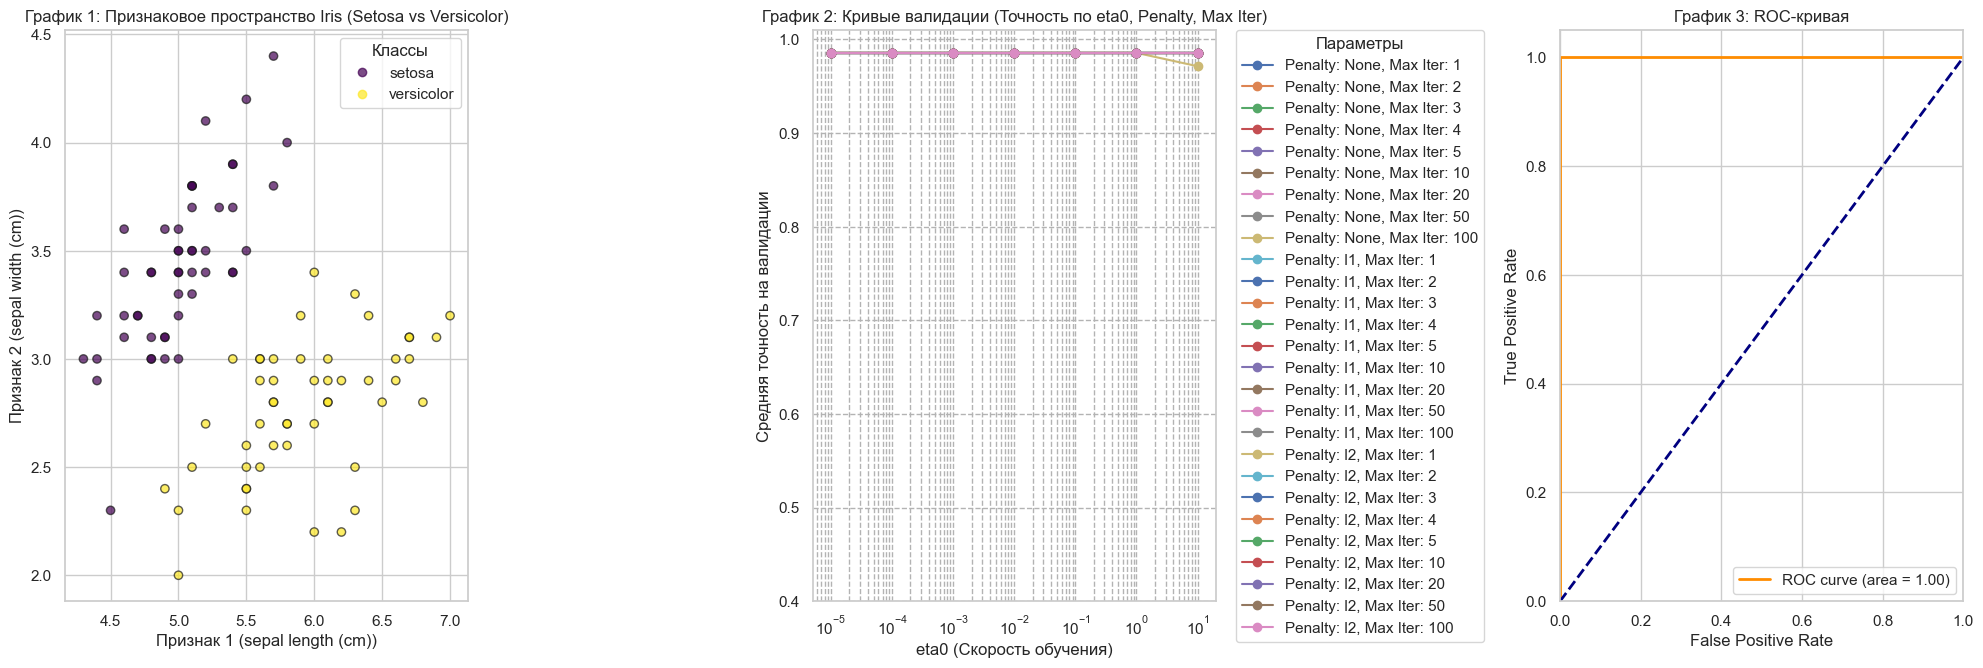

In [ ]:
iris = load_iris()
X = iris.data[:, :2]
y = iris.target

mask = y < 2
X, y = X[mask], y[mask]
target_names = list(iris.target_names[[0, 1]])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
X_s = scaler.transform(X)

# Scatter plot 
plt.figure(figsize=(20, 7))
plt.subplot(1, 3, 1)
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolors="k", alpha=0.7)
plt.title("График 1: Признаковое пространство Iris (Setosa vs Versicolor)")
plt.xlabel(f"Признак 1 ({iris.feature_names[0]})")
plt.ylabel(f"Признак 2 ({iris.feature_names[1]})")
plt.legend(handles=scatter.legend_elements()[0], labels=target_names, title="Классы")


# Grid Search 
param_grid = {
    'eta0': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0], 
    'penalty': [None, 'l1', 'l2'], 
    'max_iter': [1, 2, 3, 4, 5, 10, 20, 50, 100] # Extended max_iter values
}
grid = GridSearchCV(Perceptron(random_state=RANDOM_STATE, tol=None), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_s, y_train)

print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучшая точность на кросс-валидации: {grid.best_score_:.2f}")

plt.subplot(1, 3, 2)
results = pd.DataFrame(grid.cv_results_)

for penalty_type in param_grid['penalty']:
    for max_iter_val in param_grid['max_iter']:
        subset = results[(results['param_penalty'] == penalty_type) & (results['param_max_iter'] == max_iter_val)]
        plt.plot(subset['param_eta0'], subset['mean_test_score'], marker='o', 
                    label=f'Penalty: {penalty_type}, Max Iter: {max_iter_val}')

plt.xscale('log')
plt.title("График 2: Кривые валидации (Точность по eta0, Penalty, Max Iter)")
plt.xlabel("eta0 (Скорость обучения)")
plt.ylabel("Средняя точность на валидации")
plt.legend(title="Параметры", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, which="both", ls="--", c=".7")
plt.ylim(0.4, 1.01)

# ROC AUC
plt.subplot(1, 3, 3)
best_perceptron = grid.best_estimator_
y_score = best_perceptron.decision_function(X_test_s)
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('График 3: ROC-кривая')
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()